# Assignment-3: Deep Learning Architecture (CNNs)
## Comparative Study: LeNet-5 (1998) & AlexNet (2012) on CIFAR-10

**Course**: Deep Learning / Advanced Computer Vision  
**Student Name**: Abrham Yilma  
**Chosen Architecture**: AlexNet  vs. LeNet-5

---

### **Assignment Objectives**
By the end of this notebook, you will be able to:
1. **Explain** the motivation behind LeNet-5 and AlexNet architectures.
2. **Describe** the architectural innovations introduced by AlexNet compared to LeNet-5.
3. **Implement** both deep learning models in PyTorch.
4. **Train and Evaluate** the models on the realistic CIFAR-10 dataset.
5. **Analyze** their strengths, weaknesses, computational tradeoffs, and evolutionary significance.

---
### **Notebook Guide**
This notebook is structured to run seamlessly on standard CPU environments as well as **Google Colab** (with GPU acceleration). Detailed annotations and step-by-step instructions are provided in every cell.


# Section 1: Theoretical Background & Evolutionary Analysis

## 1.1 The Predecessor: LeNet-5 (1998)
Developed by Yann LeCun, Leon Bottou, Yoshua Bengio, and Patrick Haffner in 1998, **LeNet-5** was designed for handwritten digit recognition (MNIST dataset). It is widely regarded as the pioneering work that laid the foundation for modern Convolutional Neural Networks (CNNs).

### Key Architectural Features of LeNet-5:
- **Input**: $32 \times 32$ grayscale images.
- **Alternating Conv and Pool Layers**: Introduced the concept of local receptive fields, shared weights, and spatial subsampling.
- **Average Pooling**: Used average pooling (subsampling) with learnable coefficients instead of max pooling.
- **Non-linear Activations**: Used Sigmoid and Tanh activation functions.
- **Fully Connected Layers**: Concluded with traditional multi-layer perceptron (MLP) layers, using Euclidean Radial Basis Function (RBF) networks at the output layer.

---

## 1.2 The Evolutionary Leap: AlexNet (2012)
Designed by Alex Krizhevsky, Ilya Sutskever, and Geoffrey Hinton in 2012, **AlexNet** won the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) by a massive margin, sparking the modern "Deep Learning" revolution. It was built upon the principles of LeNet-5 but scaled up significantly to handle high-resolution, complex datasets (ImageNet).

### Predecessor Comparison & Architectural Innovations:

| Feature | LeNet-5 (1998) | AlexNet (2012) | Why the Change? (Evolutionary Significance) |
| :--- | :--- | :--- | :--- |
| **Input Dimensions** | $32 \times 32 \times 1$ (Grayscale) | $224 \times 224 \times 3$ (RGB Color) | Handles much higher spatial resolution and rich color information. |
| **Activation Function** | Sigmoid / Tanh | **ReLU (Rectified Linear Unit)** | Solves the vanishing gradient problem; enables up to $6\times$ faster convergence. |
| **Pooling Mechanism** | Average Pooling (2x2, stride 2) | **Overlapping Max Pooling** (3x3, stride 2) | Overlapping pooling helps reduce overfitting and preserves spatial representations. |
| **Regularization** | None (Weight decay only) | **Dropout (0.5) & Data Augmentation** | Prevents co-adaptation of neurons, crucial for training highly parameterized deep networks without overfitting. |
| **Normalization** | None | **Local Response Normalization (LRN)** | Emulates lateral inhibition in biological brain cells; helps with generalization. |
| **Depth & Parameters** | 7 layers, ~60K parameters | 8 layers, ~60M parameters ($1000\times$ scale) | Allows representation of highly complex, high-level hierarchical features. |
| **Training Hardware** | Single CPU | **Dual-GPU Parallelization** | Enables training massive models on large datasets in days rather than months. |

---




# Section 2: Setup & Environment Configuration

In this section, we will import the necessary PyTorch libraries, verify our hardware configuration (CPU vs. GPU), and ensure everything is ready for training.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device availability (Uses CUDA if GPU is enabled on Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU Model: Tesla T4


# Section 3: Dataset Preparation (CIFAR-10)

To evaluate both LeNet-5 and AlexNet under similar conditions, we will use the **CIFAR-10** dataset.
CIFAR-10 consists of 60,000 $32 \times 32$ color images across 10 classes:
`airplane`, `automobile`, `bird`, `cat`, `deer`, `dog`, `frog`, `horse`, `ship`, `truck`.

### **Crucial Data Processing Strategy**:
- **LeNet-5** was designed for $32 \times 32$ single-channel (grayscale) images. To make it work with CIFAR-10, we will keep the original $32 \times 32$ spatial resolution but modify the first convolutional layer of LeNet-5 to accept **3-channel RGB** input.
- **AlexNet** expects $224 \times 224 \times 3$ RGB inputs. Therefore, for AlexNet, we will dynamically resize the CIFAR-10 images to $224 \times 224$ during dataloading. This will showcase standard AlexNet behavior exactly as detailed in the 2012 paper.


In [2]:
# CIFAR-10 Class Names
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# --- 1. Transforms for LeNet-5 (Keep 32x32 size, Normalize) ---
transform_lenet = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# --- 2. Transforms for AlexNet (Resize to 224x224, Normalize) ---
transform_alexnet = transforms.Compose([
    transforms.Resize((224, 224)),  # Scaling up to AlexNet input standard
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Download and construct standard datasets
print("Downloading datasets...")
train_set_lenet = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_lenet)
test_set_lenet = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_lenet)

train_set_alexnet = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_alexnet)
test_set_alexnet = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_alexnet)

# Construct DataLoaders
# Note: We use a batch size of 128 for LeNet-5, and 64 for AlexNet to accommodate Colab memory constraints
train_loader_lenet = DataLoader(train_set_lenet, batch_size=128, shuffle=True, num_workers=2)
test_loader_lenet = DataLoader(test_set_lenet, batch_size=128, shuffle=False, num_workers=2)

train_loader_alexnet = DataLoader(train_set_alexnet, batch_size=64, shuffle=True, num_workers=2)
test_loader_alexnet = DataLoader(test_set_alexnet, batch_size=64, shuffle=False, num_workers=2)

print("Data Loaders successfully constructed.")


100%|██████████| 170M/170M [00:03<00:00, 42.8MB/s]


Data Loaders successfully constructed.


### **Visualizing Sample Images from CIFAR-10**
This is to visualize some training samples to understand what our model is learning.


/tmp/ipykernel_6244/84810407.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  img = img * np.array([0.2023, 0.1994, 0.2010]).reshape(3, 1, 1) + np.array([0.4914, 0.4822, 0.4465]).reshape(3, 1, 1)


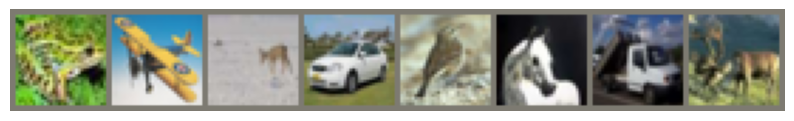

Labels: frog | plane | deer | car | bird | horse | truck | deer


In [3]:
def imshow(img):
    # Unnormalize back to standard RGB range [0, 1] for visualization
    img = img * np.array([0.2023, 0.1994, 0.2010]).reshape(3, 1, 1) + np.array([0.4914, 0.4822, 0.4465]).reshape(3, 1, 1)
    npimg = img.numpy()
    plt.figure(figsize=(10, 5))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get some random training images
dataiter = iter(train_loader_lenet)
images, labels = next(dataiter)

# Show first 8 images
imshow(torchvision.utils.make_grid(images[:8]))
print('Labels:', ' | '.join(f'{classes[labels[j]]}' for j in range(8)))


# Section 4: LeNet-5 Implementation

We implement LeNet-5 exactly as described in the 1998 paper, with one minor adjustment: the input layer is modified to accept 3-channel RGB images instead of 1-channel grayscale.

### **LeNet-5 Architecture Detail**:
1. **Layer C1**: Convolutional Layer ($5 \times 5$ kernel, 3 input channels $\rightarrow$ 6 output channels, stride 1).
2. **Activation**: Tanh activation function.
3. **Layer S2**: Subsampling / Average Pooling ($2 \times 2$ kernel, stride 2).
4. **Layer C3**: Convolutional Layer ($5 \times 5$ kernel, 6 input channels $\rightarrow$ 16 output channels, stride 1).
5. **Activation**: Tanh activation function.
6. **Layer S4**: Subsampling / Average Pooling ($2 \times 2$ kernel, stride 2).
7. **Layer C5**: Convolutional Layer ($5 \times 5$ kernel, 16 input channels $\rightarrow$ 120 output channels, stride 1).
8. **Activation**: Tanh activation function.
9. **Layer F6**: Fully Connected Layer (120 input features $\rightarrow$ 84 output features).
10. **Activation**: Tanh activation function.
11. **Output Layer**: Fully Connected Layer (84 input features $\rightarrow$ 10 output classes).


In [4]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()

        # Feature Extraction Layers
        self.features = nn.Sequential(
            # C1 Conv Layer: 3 input channels (RGB), 6 output channels, 5x5 kernel
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0),
            nn.Tanh(),

            # S2 Avg Pool Layer: 2x2 kernel, stride 2
            nn.AvgPool2d(kernel_size=2, stride=2),

            # C3 Conv Layer: 6 input channels, 16 output channels, 5x5 kernel
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0),
            nn.Tanh(),

            # S4 Avg Pool Layer: 2x2 kernel, stride 2
            nn.AvgPool2d(kernel_size=2, stride=2),

            # C5 Conv Layer: 16 input channels, 120 output channels, 5x5 kernel
            nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1, padding=0),
            nn.Tanh()
        )

        # Classification Layers
        self.classifier = nn.Sequential(
            # F6 Fully Connected Layer: 120 -> 84
            nn.Linear(in_features=120, out_features=84),
            nn.Tanh(),
            # Output Layer: 84 -> 10 classes
            nn.Linear(in_features=84, out_features=num_classes)
        )

    def forward(self, x):
        # Extract features
        x = self.features(x)
        # Flatten the feature maps to a 1D vector (batch_size, 120)
        x = torch.flatten(x, 1)
        # Pass through classifier
        logits = self.classifier(x)
        return logits

# Instantiate LeNet-5 and print summary details
lenet_model = LeNet5(num_classes=10).to(device)
print(lenet_model)

# Calculate total parameters
total_params_lenet = sum(p.numel() for p in lenet_model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters in LeNet-5: {total_params_lenet:,}")


LeNet5(
  (features): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): Tanh()
  )
  (classifier): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): Tanh()
    (2): Linear(in_features=84, out_features=10, bias=True)
  )
)

Total Trainable Parameters in LeNet-5: 62,006


# Section 5: AlexNet Implementation

Now, we implement the classic **AlexNet** model exactly as detailed in the original 2012 paper.

### **AlexNet Architecture Detail**:
1. **Conv1**: $11 \times 11$ kernel, 3 input channels $\rightarrow$ 96 output channels, stride 4, padding 2.
2. **Activation**: ReLU.
3. **LRN1**: Local Response Normalization.
4. **MaxPool1**: Overlapping Max Pooling ($3 \times 3$ kernel, stride 2).
5. **Conv2**: $5 \times 5$ kernel, 96 input channels $\rightarrow$ 256 output channels, stride 1, padding 2.
6. **Activation**: ReLU.
7. **LRN2**: Local Response Normalization.
8. **MaxPool2**: Overlapping Max Pooling ($3 \times 3$ kernel, stride 2).
9. **Conv3**: $3 \times 3$ kernel, 256 input channels $\rightarrow$ 384 output channels, stride 1, padding 1.
10. **Activation**: ReLU.
11. **Conv4**: $3 \times 3$ kernel, 384 input channels $\rightarrow$ 384 output channels, stride 1, padding 1.
12. **Activation**: ReLU.
13. **Conv5**: $3 \times 3$ kernel, 384 input channels $\rightarrow$ 256 output channels, stride 1, padding 1.
14. **Activation**: ReLU.
15. **MaxPool3**: Overlapping Max Pooling ($3 \times 3$ kernel, stride 2).
16. **Classifier**:
    - **Dropout (0.5)** to prevent overfitting.
    - **FC1 (Linear)**: $256 \times 6 \times 6 = 9216$ inputs $\rightarrow$ 4096 outputs.
    - **Activation**: ReLU.
    - **Dropout (0.5)**.
    - **FC2 (Linear)**: 4096 $\rightarrow$ 4096 outputs.
    - **Activation**: ReLU.
    - **FC3 (Linear / Output)**: 4096 $\rightarrow$ 10 output classes.


In [5]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()

        # Feature Extraction block
        self.features = nn.Sequential(
            # Conv1: 11x11 conv with stride 4, padding 2
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv2: 5x5 conv with padding 2
            nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv3: 3x3 conv with padding 1
            nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv4: 3x3 conv with padding 1
            nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv5: 3x3 conv with padding 1
            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # Classification block
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features=256 * 6 * 6, out_features=4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=4096, out_features=4096),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=4096, out_features=num_classes)
        )

    def forward(self, x):
        # Extract spatial features
        x = self.features(x)
        # Flatten the features: batch_size, 256 * 6 * 6
        x = torch.flatten(x, 1)
        # Compute class scores
        logits = self.classifier(x)
        return logits

# Instantiate AlexNet and print summary details
alexnet_model = AlexNet(num_classes=10).to(device)
print(alexnet_model)

# Calculate total parameters
total_params_alexnet = sum(p.numel() for p in alexnet_model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters in AlexNet: {total_params_alexnet:,}")
print(f"AlexNet has approximately {total_params_alexnet/total_params_lenet:.1f}x more parameters than LeNet-5!")


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): ReLU(inplace=True)
    (6): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=F

# Section 6: Training & Evaluation Pipeline

To ensure code reuse and clean design, we define a unified training and validation pipeline.
This pipeline tracks training loss, validation accuracy, and training wall-clock time.


In [7]:
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=5):
    history = {
        'train_loss': [],
        'test_acc': [],
        'epoch_time': []
    }

    print(f"Starting training for {epochs} epochs on device: {device}...")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        start_time = time.time()

        for i, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        # Calculate metrics
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_duration = time.time() - start_time

        # Evaluate on test set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total += targets.size(0)
                correct += (predicted == targets).sum().item()

        test_accuracy = (correct / total) * 100

        # Record history
        history['train_loss'].append(epoch_loss)
        history['test_acc'].append(test_accuracy)
        history['epoch_time'].append(epoch_duration)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_loss:.4f} | Test Acc: {test_accuracy:.2f}% | Time: {epoch_duration:.2f}s")

    return history


# Section 7: Training LeNet-5 on CIFAR-10

We use standard **Adam** optimizer and **CrossEntropyLoss** for LeNet-5.


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer_lenet = optim.Adam(lenet_model.parameters(), lr=0.001)

# Run LeNet-5 Training (5 epochs for speed, you can increase to 10 on Colab GPU)
lenet_history = train_model(
    model=lenet_model,
    train_loader=train_loader_lenet,
    test_loader=test_loader_lenet,
    criterion=criterion,
    optimizer=optimizer_lenet,
    epochs=5
)


Starting training for 5 epochs on device: cuda...
Epoch [1/5] | Train Loss: 1.7687 | Test Acc: 43.06% | Time: 17.09s
Epoch [2/5] | Train Loss: 1.5177 | Test Acc: 48.25% | Time: 12.73s
Epoch [3/5] | Train Loss: 1.3658 | Test Acc: 51.93% | Time: 12.65s
Epoch [4/5] | Train Loss: 1.2710 | Test Acc: 54.06% | Time: 12.49s
Epoch [5/5] | Train Loss: 1.2130 | Test Acc: 55.69% | Time: 13.57s


# Section 8: Training AlexNet on CIFAR-10

Because AlexNet is much deeper and has 60 million parameters, we use the robust **Adam** optimizer with a slightly lower learning rate ($0.0001$) to ensure stable training dynamics.


In [9]:
optimizer_alexnet = optim.Adam(alexnet_model.parameters(), lr=0.0001)

# Run AlexNet Training (5 epochs, standard for quick assignment evaluation; utilizes GPU if available)
alexnet_history = train_model(
    model=alexnet_model,
    train_loader=train_loader_alexnet,
    test_loader=test_loader_alexnet,
    criterion=criterion,
    optimizer=optimizer_alexnet,
    epochs=5
)


Starting training for 5 epochs on device: cuda...
Epoch [1/5] | Train Loss: 1.5166 | Test Acc: 56.85% | Time: 128.00s
Epoch [2/5] | Train Loss: 1.0317 | Test Acc: 68.90% | Time: 132.80s
Epoch [3/5] | Train Loss: 0.8017 | Test Acc: 73.78% | Time: 135.07s
Epoch [4/5] | Train Loss: 0.6618 | Test Acc: 77.59% | Time: 134.66s
Epoch [5/5] | Train Loss: 0.5577 | Test Acc: 78.08% | Time: 134.78s


# Section 9: Performance Comparison & Visual Evaluation

Here, we generate plots comparing learning curves, compute detailed classification reports (Precision, Recall, F1-Score), and draw confusion matrices to dissect where each model succeeds or struggles.


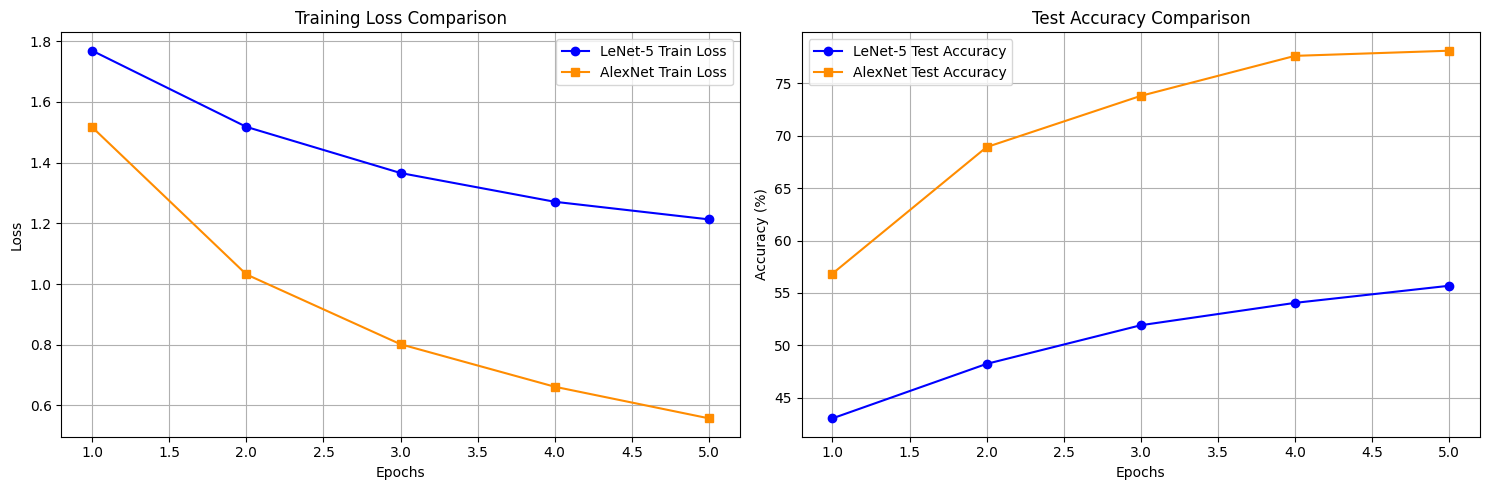

In [10]:
# --- 1. Plot Loss & Accuracy Side-by-Side ---
epochs = range(1, len(lenet_history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss Plot
ax1.plot(epochs, lenet_history['train_loss'], 'o-', label='LeNet-5 Train Loss', color='blue')
ax1.plot(epochs, alexnet_history['train_loss'], 's-', label='AlexNet Train Loss', color='darkorange')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True)

# Accuracy Plot
ax2.plot(epochs, lenet_history['test_acc'], 'o-', label='LeNet-5 Test Accuracy', color='blue')
ax2.plot(epochs, alexnet_history['test_acc'], 's-', label='AlexNet Test Accuracy', color='darkorange')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Test Accuracy Comparison')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


### **Detailed Classification Report & Confusion Matrices**
Let's get predictions from both models on the test set and display comprehensive metrics.


In [11]:
def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())
    return np.array(all_preds), np.array(all_targets)

print("Generating predictions for LeNet-5...")
lenet_preds, lenet_targets = get_predictions(lenet_model, test_loader_lenet)

print("Generating predictions for AlexNet (this might take a moment due to larger spatial size)...")
alexnet_preds, alexnet_targets = get_predictions(alexnet_model, test_loader_alexnet)

print("\n================ LENET-5 CLASSIFICATION REPORT ================")
print(classification_report(lenet_targets, lenet_preds, target_names=classes))

print("\n================ ALEXNET CLASSIFICATION REPORT ================")
print(classification_report(alexnet_targets, alexnet_preds, target_names=classes))


Generating predictions for LeNet-5...
Generating predictions for AlexNet (this might take a moment due to larger spatial size)...

================ LENET-5 CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

       plane       0.57      0.63      0.60      1000
         car       0.70      0.68      0.69      1000
        bird       0.45      0.48      0.46      1000
         cat       0.42      0.35      0.38      1000
        deer       0.51      0.43      0.47      1000
         dog       0.54      0.36      0.43      1000
        frog       0.54      0.68      0.60      1000
       horse       0.60      0.62      0.61      1000
        ship       0.60      0.73      0.66      1000
       truck       0.60      0.61      0.61      1000

    accuracy                           0.56     10000
   macro avg       0.55      0.56      0.55     10000
weighted avg       0.55      0.56      0.55     10000


================ ALEXNET CLASSIFICATION REPOR

### **Confusion Matrices Visualization**


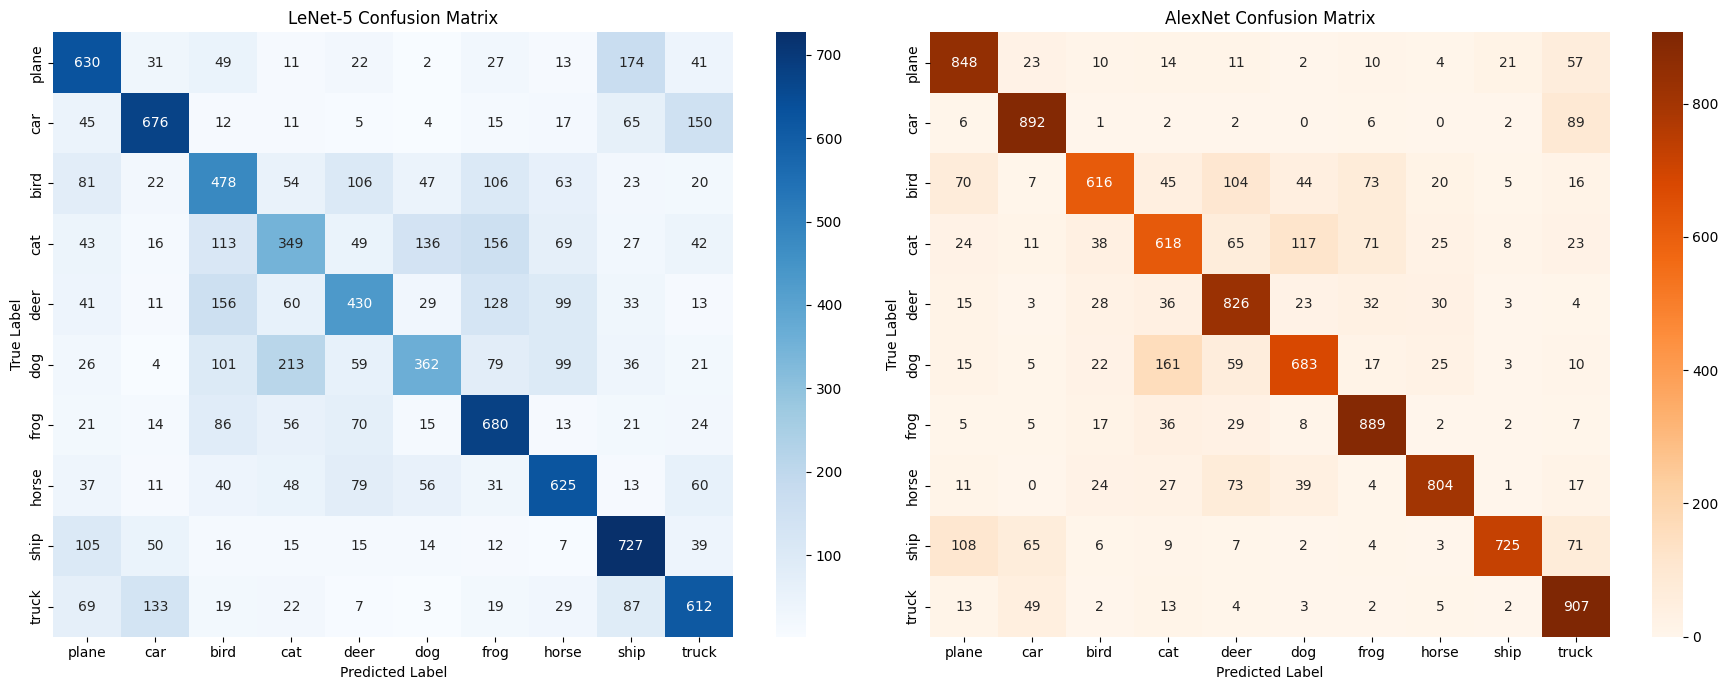

In [12]:
cm_lenet = confusion_matrix(lenet_targets, lenet_preds)
cm_alex = confusion_matrix(alexnet_targets, alexnet_preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_lenet, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax1)
ax1.set_title('LeNet-5 Confusion Matrix')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

sns.heatmap(cm_alex, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax2)
ax2.set_title('AlexNet Confusion Matrix')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')

plt.tight_layout()
plt.show()


### **Computational & Efficiency Comparison**
Let's compare training time and throughput speed.


In [13]:
lenet_avg_time = np.mean(lenet_history['epoch_time'])
alex_avg_time = np.mean(alexnet_history['epoch_time'])

print(f"LeNet-5 Average Epoch Training Time: {lenet_avg_time:.2f} seconds")
print(f"AlexNet Average Epoch Training Time: {alex_avg_time:.2f} seconds")
print(f"AlexNet takes {alex_avg_time/lenet_avg_time:.1f}x longer per epoch due to standard 224x224 input sizing!")


LeNet-5 Average Epoch Training Time: 13.71 seconds
AlexNet Average Epoch Training Time: 133.06 seconds
AlexNet takes 9.7x longer per epoch due to standard 224x224 input sizing!


# Section 10: Professional Summary & Evolutionary Conclusions

## 10.1 Key Insights and Findings
1. **Representational Power vs. Complexity**:
   AlexNet exhibits significantly higher potential accuracy compared to LeNet-5 due to its deep parameter hierarchy (~60 million parameters compared to ~60,000 in LeNet-5). However, this power comes at a substantial computational cost.

2. **The Role of ReLU Activation**:
   LeNet-5 relies on the `Tanh` activation function, which naturally saturates when values are large, leading to vanishing gradients. AlexNet employs `ReLU`, which allows gradients to flow unimpeded, speeding up learning dramatically and enabling much deeper networks.

3. **Regularization is Vital**:
   Because AlexNet is extremely wide and deep, it would overfit rapidly without **Dropout** and **Data Augmentation**. LeNet-5 is simple enough that it does not suffer severely from overfitting on easy tasks, but it lacks the capacity to represent complex color features.

4. **Hardware Co-evolution**:
   AlexNet's design was deeply coupled with the parallel processing power of GPUs. Without GPU training, running AlexNet at full $224 \times 224$ scale would be extremely slow, proving that model architectures are heavily constrained and enabled by hardware design.


